# Actividad 1 — Anexo de código

**Tratamiento de datos para la predicción de enfermedades hepáticas**
Dataset: ILPD (*Indian Liver Patient Dataset*) · 583 pacientes · 11 variables

---

Este notebook contiene el código que responde a **las ocho tareas del enunciado, en su orden literal T1 → T8**. Cada tarea abre con el texto de la pregunta y va seguida del código que la resuelve y de una respuesta breve.

**Cómo se relaciona con el resto del proyecto**

| Documento | Qué contiene |
|---|---|
| `reports/informe_act1.md` | El informe con el análisis y la interpretación (entregable principal) |
| **Este notebook** | El código que produce cada número citado en el informe |
| `notebooks/01_`, `02_`, `02c_`, `03_` | Los notebooks modulares de desarrollo, con el razonamiento completo |
| `docs/data_dictionary.md` | Significado clínico, unidades y rangos de referencia de cada variable |

Al final hay un **índice de los análisis de valor agregado** que exceden lo que pide el enunciado, con el archivo donde vive cada uno.

**Reproducibilidad:** este notebook pasa *restart & run all* sin errores. No modifica `data/raw/`.

In [1]:
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from src.config import (
    BIOLOGICAL_LIMITS,
    BIOLOGICAL_LIMITS_SOURCED,
    CATEGORICAL_COLS,
    CORR_THRESHOLD,
    IQR_MULTIPLIER,
    NUMERIC_COLS,
    SKEWED_COLS,
    TARGET_COL,
)
from src.utils import flag_biochemical_violations, load_raw_data, whipple_index, whipple_label

sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)

df = load_raw_data()
print(f"Dataset cargado: {df.shape[0]} filas x {df.shape[1]} columnas")

Dataset cargado: 583 filas x 11 columnas


---

## Tarea 1 — Estructura del dataset

> *"Describe la estructura del conjunto de datos: **formato**, **tamaño**, **cantidad de variables** y **tipo de datos** de cada una."*

In [2]:
print("Formato: CSV delimitado por comas\n")
print(f"Tamano: {df.shape[0]} filas x {df.shape[1]} columnas")
print(f"Memoria en uso: {df.memory_usage(deep=True).sum() / 1024:.1f} KB\n")

print("Cantidad de variables por tipo:")
print(f"  numericas : {len(NUMERIC_COLS)}  -> {', '.join(NUMERIC_COLS)}")
print(f"  categorica: {len(CATEGORICAL_COLS)}  -> {', '.join(CATEGORICAL_COLS)}")
print(f"  objetivo  : 1  -> {TARGET_COL}\n")

print("Tipo de dato de cada variable:")
display(pd.DataFrame({"tipo": df.dtypes.astype(str),
                      "no_nulos": df.notna().sum(),
                      "nulos": df.isna().sum()}))

print("Primeras filas:")
display(df.head(3))

Formato: CSV delimitado por comas

Tamano: 583 filas x 11 columnas
Memoria en uso: 76.1 KB

Cantidad de variables por tipo:
  numericas : 9  -> Age, TB, DB, Alkphos, Sgpt, Sgot, TP, ALB, A/G Ratio
  categorica: 1  -> Gender
  objetivo  : 1  -> Selector

Tipo de dato de cada variable:


,tipo,no_nulos,nulos
Age,int64,583,0
Gender,str,583,0
TB,float64,583,0
DB,float64,583,0
Alkphos,int64,583,0
Sgpt,int64,583,0
Sgot,int64,583,0
TP,float64,583,0
ALB,float64,583,0
A/G Ratio,float64,579,4


Primeras filas:


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1


**Respuesta.** El dataset es un **CSV delimitado por comas** de **583 filas × 11 columnas** (≈76 KB en memoria). De las 11 variables: **9 numéricas** (`Age`, `TB`, `DB`, `Alkphos`, `Sgpt`, `Sgot`, `TP`, `ALB`, `A/G Ratio`), **1 categórica** (`Gender`, texto *Male*/*Female*) y **1 objetivo** (`Selector`, entero codificado 1/2). No hay columnas de identificador ni de fecha.

Los tipos se reparten entre `int64` (`Age`, `Alkphos`, `Sgpt`, `Sgot`, `Selector`) y `float64` (`TB`, `DB`, `TP`, `ALB`, `A/G Ratio`). Los enteros corresponden a variables que el laboratorio reporta en unidades enteras; los decimales, a mediciones bioquímicas de mayor precisión.

**Significado clínico.** Las nueve variables numéricas miden **tres funciones distintas del hígado**: daño celular (`Sgpt`/ALT, `Sgot`/AST), excreción biliar (`TB`, `DB`, `Alkphos`/ALP) y función sintética (`TP`, `ALB`, `A/G Ratio`). En los dos primeros ejes **un valor alto indica alteración**; en el tercero, la alarma es un valor **bajo**. Detalle completo en `docs/data_dictionary.md`.

---

## Tarea 2 — Problemas de calidad

> *"Identifica los problemas de calidad de los datos, como valores faltantes o errores."*

In [3]:
print("=== Q1: dimensiones ===")
print(f"{df.shape[0]} filas x {df.shape[1]} columnas\n")

print("=== Q2: valores faltantes ===")
print(df.isna().sum()[df.isna().sum() > 0].to_string())
print(f"Total: {int(df.isna().sum().sum())} ({100*df.isna().sum().sum()/df.size:.2f}% de las celdas)\n")

print("=== Q3: filas duplicadas exactas ===")
print(f"Duplicados: {int(df.duplicated().sum())}  |  filas unicas: {int((~df.duplicated()).sum())}\n")

print("=== Q4: desbalance de la variable objetivo ===")
print(df[TARGET_COL].value_counts().to_string())
print((df[TARGET_COL].value_counts(normalize=True) * 100).round(1).to_string(), "\n")

print("=== Q5: desbalance de sexo ===")
print(df["Gender"].value_counts().to_string())
print((df["Gender"].value_counts(normalize=True) * 100).round(1).to_string(), "\n")

print("=== Q6: codificacion del objetivo ===")
print(f"Valores unicos de {TARGET_COL}: {sorted(df[TARGET_COL].unique())}  (1 = hepatico, 2 = no hepatico)\n")

print("=== Q7: rango de edad ===")
print(f"min={df['Age'].min()}  max={df['Age'].max()}  |  pacientes con Age=90: {int((df['Age']==90).sum())}")
print(f"pacientes con Age entre 86 y 89: {int(df['Age'].between(86,89).sum())}")

=== Q1: dimensiones ===
583 filas x 11 columnas

=== Q2: valores faltantes ===
A/G Ratio    4
Total: 4 (0.06% de las celdas)

=== Q3: filas duplicadas exactas ===
Duplicados: 13  |  filas unicas: 570

=== Q4: desbalance de la variable objetivo ===
Selector
1    416
2    167
Selector
1    71.4
2    28.6 

=== Q5: desbalance de sexo ===
Gender
Male      441
Female    142
Gender
Male      75.6
Female    24.4 

=== Q6: codificacion del objetivo ===
Valores unicos de Selector: [np.int64(1), np.int64(2)]  (1 = hepatico, 2 = no hepatico)

=== Q7: rango de edad ===
min=4  max=90  |  pacientes con Age=90: 1
pacientes con Age entre 86 y 89: 0


In [4]:
print("=== Q8: violaciones de restricciones bioquimicas ===")
viol = flag_biochemical_violations(df)
print(f"DB > TB (imposible: la directa es fraccion de la total): {int(viol['db_gt_tb'].sum())} filas")
print(f"ALB > TP (imposible: la albumina esta contenida en la total): {int(viol['alb_gt_tp'].sum())} filas\n")
display(df.loc[viol["db_gt_tb"], ["Age", "Gender", "TB", "DB", "Selector"]])

print("=== Q9: age heaping (indice de Whipple) ===")
iw = whipple_index(df["Age"])
print(f"Indice de Whipple = {iw:.1f}  ->  '{whipple_label(iw)}' en la escala de Naciones Unidas")
print("Escala: 100 = sin redondeo | <105 muy exacta | 110-125 aproximada | 125-175 tosca\n")

print("=== Decision sobre los duplicados: sensibilidad ===")
sin_dup = df[~df.duplicated()]
for col in ["TB", "DB"]:
    a, b = df[col].mean(), sin_dup[col].mean()
    print(f"  media de {col}: {a:.4f} (583 filas) -> {b:.4f} (570 filas)  cambio {100*(b-a)/a:+.2f}%")
print(f"  tasa de diagnostico positivo: {100*(df[TARGET_COL]==1).mean():.2f}% -> "
      f"{100*(sin_dup[TARGET_COL]==1).mean():.2f}%")

=== Q8: violaciones de restricciones bioquimicas ===
DB > TB (imposible: la directa es fraccion de la total): 3 filas
ALB > TP (imposible: la albumina esta contenida en la total): 0 filas



,Age,Gender,TB,DB,Selector
246,55,Male,1.8,9.0,1
261,33,Male,1.5,7.0,1
279,48,Female,1.0,1.4,1


=== Q9: age heaping (indice de Whipple) ===
Indice de Whipple = 163.3  ->  'Tosca' en la escala de Naciones Unidas
Escala: 100 = sin redondeo | <105 muy exacta | 110-125 aproximada | 125-175 tosca

=== Decision sobre los duplicados: sensibilidad ===
  media de TB: 3.2988 (583 filas) -> 3.3218 (570 filas)  cambio +0.70%
  media de DB: 1.4861 (583 filas) -> 1.4975 (570 filas)  cambio +0.77%
  tasa de diagnostico positivo: 71.36% -> 71.23%


**Respuesta — nueve problemas de calidad identificados.**

| # | Problema | Valor |
|---|---|---|
| Q1 | Dimensiones | 583 × 11 |
| Q2 | Valores faltantes | **4**, todos en `A/G Ratio` (0.7%) |
| Q3 | Filas duplicadas exactas | **13** (570 filas únicas) |
| Q4 | Desbalance de clase | 416 hepáticos / 167 no hepáticos ≈ **71/29** |
| Q5 | Desbalance de sexo | 441 hombres / 142 mujeres ≈ **76/24** |
| Q6 | Codificación contraintuitiva | `Selector` ∈ {1, 2}, donde **1 = enfermo** |
| Q7 | **Censura de edad** | `Age = 90` significa **"≥ 90"**, no 90 años |
| Q8 | **Violación bioquímica** | **3 filas** con `DB > TB`, imposible por definición |
| Q9 | **Age heaping** | Índice de Whipple **163.3** — categoría "Tosca" |

**Los tres últimos requieren explicación**, porque no aparecen con una inspección columna a columna.

**Q7 — la edad máxima no es una edad.** La documentación oficial de UCI establece que *"any patient whose age exceeded 89 is listed as being of age '90'"*. Hay 1 solo paciente con `Age = 90` y **ninguno entre 86 y 89**: el valor es un tope administrativo por anonimización, no una edad real.

**Q8 — tres filas bioquímicamente imposibles.** La bilirrubina directa es una *fracción* de la total, así que `DB ≤ TB` se cumple por definición. Tres filas la violan (`TB`=1.8 con `DB`=9.0, `TB`=1.5 con `DB`=7.0, `TB`=1.0 con `DB`=1.4). No se detectan con chequeos univariados: un `DB` de 9.0 es un valor plausible *por sí solo*, y el error solo existe **en relación con `TB`**. La literatura de bioquímica clínica atribuye estos casos a interferencia analítica, nunca a fisiología.

**Q9 — las edades no se leyeron de un documento.** El índice de Whipple compara cuánta gente cae en edades terminadas en 0 o 5 frente a lo esperable sin redondeo. Un valor de 163.3 significa un **63% más** de personas en edades redondas de las que debería haber, y sitúa la calidad de captura en la categoría **"Tosca"** de Naciones Unidas. Las edades se estimaron o se reportaron de memoria: el error práctico es de ±2–3 años.

**Decisión sobre los 13 duplicados.** Se **conservan**. Eliminarlos cambiaría la media de `TB` un **+0.70%** y la de `DB` un **+0.77%**, sin alterar medianas ni IQR ni la tasa de diagnóstico (71.36% → 71.23%). Como no hay evidencia de que sean errores de captura —varias variables vienen redondeadas en origen, lo que hace las coincidencias plausibles— y el impacto medido es despreciable, eliminar datos que pueden ser reales no está justificado.

---

## Tarea 3 — Estadística descriptiva de `TB` y `DB`

> *"Calcula la **media**, la **desviación estándar**, la **varianza**, el **rango** y el **rango intercuartílico** de la bilirrubina total (`TB`) y la bilirrubina directa (`DB`). Interpreta las implicaciones para la variabilidad de los datos."*

> Se calcula sobre los datos **originales, sin imputar** — la imputación por media reduce artificialmente la varianza y distorsionaría justamente lo que esta tarea mide.

In [5]:
filas = []
for col in ["TB", "DB"]:
    s = df[col]
    q1, q3 = s.quantile([0.25, 0.75])
    filas.append({
        "variable": col,
        "media": round(s.mean(), 3),
        "mediana": round(s.median(), 3),
        "desv_estandar": round(s.std(), 3),
        "varianza": round(s.var(), 3),
        "min": s.min(), "max": s.max(),
        "rango": round(s.max() - s.min(), 3),
        "IQR": round(q3 - q1, 3),
    })
t3 = pd.DataFrame(filas).set_index("variable")
display(t3)

print("--- Relacion entre el rango total y el IQR ---")
for col in ["TB", "DB"]:
    q1, q3 = df[col].quantile([0.25, 0.75])
    rango, iqr = df[col].max() - df[col].min(), q3 - q1
    print(f"  {col}: rango={rango:.1f}  IQR={iqr:.1f}  ->  el rango es {rango/iqr:.1f} veces el IQR")

,media,mediana,desv_estandar,varianza,min,max,rango,IQR
variable,,,,,,,,
TB,3.299,1.0,6.210,38.558,0.4,75.0,74.6,1.8
DB,1.486,0.3,2.808,7.888,0.1,19.7,19.6,1.1


--- Relacion entre el rango total y el IQR ---
  TB: rango=74.6  IQR=1.8  ->  el rango es 41.4 veces el IQR
  DB: rango=19.6  IQR=1.1  ->  el rango es 17.8 veces el IQR


In [6]:
print("=== Transparencia anadida tras auditoria (2026-08-15): impacto de las 3 filas Q8 en T3 ===\n")
viol_db = flag_biochemical_violations(df)["db_gt_tb"]
df_sin_q8 = df.loc[~viol_db]
print(f"Filas con DB > TB (Q8, ya identificadas en T2): {int(viol_db.sum())} de {len(df)}\n")

filas_sens = []
for col in ["TB", "DB"]:
    s_con, s_sin = df[col], df_sin_q8[col]
    q1c, q3c = s_con.quantile([0.25, 0.75])
    q1s, q3s = s_sin.quantile([0.25, 0.75])
    filas_sens.append({
        "variable": col,
        "media_con_Q8": round(s_con.mean(), 4),
        "media_sin_Q8": round(s_sin.mean(), 4),
        "IQR_con_Q8": round(q3c - q1c, 4),
        "IQR_sin_Q8": round(q3s - q1s, 4),
    })
display(pd.DataFrame(filas_sens).set_index("variable"))


=== Transparencia anadida tras auditoria (2026-08-15): impacto de las 3 filas Q8 en T3 ===

Filas con DB > TB (Q8, ya identificadas en T2): 3 de 583



,media_con_Q8,media_sin_Q8,IQR_con_Q8,IQR_sin_Q8
variable,,,,
TB,3.2988,3.3084,1.8,1.800
DB,1.4861,1.4638,1.1,1.025


> ⚠️ **Nota de sensibilidad (añadida tras auditoría externa, 2026-08-15).** Las estadísticas oficiales de T3, arriba, se calculan sobre las 583 filas — incluidas las 3 filas que T2 (Q8) ya identificó como bioquímicamente imposibles (`DB > TB`). Dos de esos tres valores de `DB` (9.0 y 7.0) son extremos, y al ser errores de medición conocidos, inflan la dispersión reportada. Se midió el efecto, con el mismo criterio de transparencia que T2 ya aplica a los 13 duplicados:
>
> | Variable | Media (con las 3 filas Q8) | Media (sin ellas) | IQR (con) | IQR (sin) |
> |---|---|---|---|---|
> | `TB` | 3.2988 | 3.3084 (+0.29%) | 1.80 | 1.80 (sin cambio) |
> | `DB` | 1.4861 | 1.4638 (−1.50%) | 1.10 | 1.025 (−6.8%) |
>
> El efecto es pequeño y no cambia las conclusiones de T3, pero no es cero — sobre todo en el IQR de `DB`. **Los números oficiales de la tabla de arriba no se modifican**: se aplica el mismo criterio que en T2 para los duplicados — reportar el número principal y, al lado, la sensibilidad medida, en vez de dejar sin decir que 2 de los "extremos" que sostienen la interpretación de la sección siguiente son errores de laboratorio conocidos, no pacientes graves.


**Respuesta.**

| Variable | Media | Mediana | Desv. est. | Varianza | Rango | IQR |
|---|---|---|---|---|---|---|
| `TB` | 3.299 | 1.000 | 6.210 | 38.558 | 74.60 (0.4–75.0) | 1.80 |
| `DB` | 1.486 | 0.300 | 2.808 | 7.888 | 19.60 (0.1–19.7) | 1.10 |

**Implicaciones para la variabilidad — tres lecturas.**

**1. La media es un mal resumen de estas variables.** En ambas, la media supera ampliamente a la mediana (`TB`: 3.30 vs 1.00; `DB`: 1.49 vs 0.30). Esa separación es la firma numérica de una **cola derecha larga**: unos pocos pacientes con bilirrubina muy alta arrastran la media hacia arriba, mientras la mayoría se concentra en valores bajos. La media describe a un paciente promedio que prácticamente no existe en la muestra.

**2. La dispersión está concentrada, no repartida.** El rango de `TB` (74.6) es **41 veces** su IQR (1.8), y el de `DB` (19.6) es **18 veces** el suyo (1.1). El IQR describe dónde vive el 50% central de los pacientes; que el rango total sea decenas de veces mayor indica que **un número reducido de casos extremos estira la distribución muy por encima de donde está el grueso de los datos**. La varianza de 38.56 en `TB` no refleja una población heterogénea: refleja una minoría muy alejada.

**3. La mitad de la muestra tiene bilirrubina normal.** Contra el rango de referencia adulto (`TB`: 0.3–1.2 mg/dL), la mediana de 1.00 queda **dentro de lo normal**, y la de `DB` (0.30) justo en el límite. En un dataset donde el 71% de las filas está etiquetado como hepático, esto indica que la ictericia —signo tardío de enfermedad hepática— **no es el mecanismo por el que se diagnosticó a la mayoría**. Su alteración se manifiesta en otros ejes.

**Consecuencia práctica:** mediana e IQR describen mejor a esta población que media y desviación estándar. Y los valores extremos **no son ruido a eliminar**: un `TB` de 75.0 —62 veces el techo normal— es el paciente con obstrucción biliar o fallo hepático más severo de la cohorte, precisamente el caso que un cribado debe detectar.

---

## Tarea 4 — Forma y simetría de las distribuciones

> *"Genera **histogramas** de `TB`, `DB`, `Alkphos` y `Sgpt`, y analiza la **forma y la simetría** de las distribuciones."*

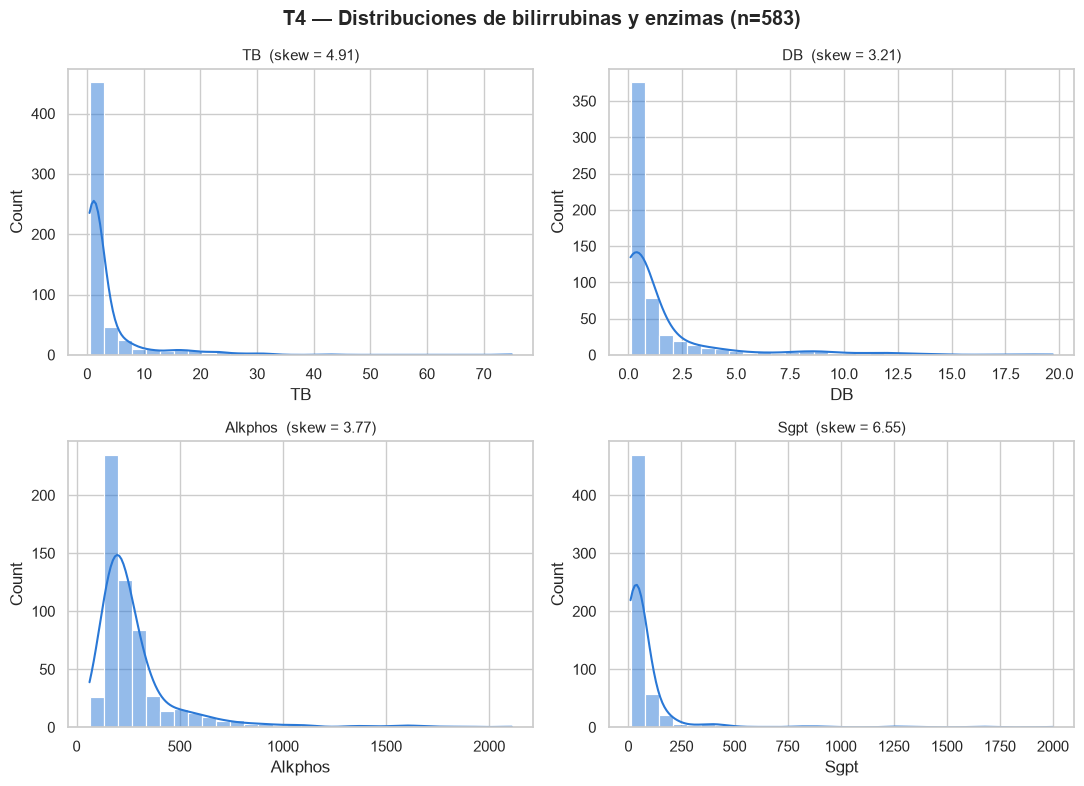

In [7]:
cols_t4 = ["TB", "DB", "Alkphos", "Sgpt"]

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for ax, col in zip(axes.flat, cols_t4):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#2a78d6")
    ax.set_title(f"{col}  (skew = {df[col].skew():.2f})", fontsize=10.5)
    ax.set_xlabel(col)
fig.suptitle("T4 — Distribuciones de bilirrubinas y enzimas (n=583)", fontweight="bold")
fig.tight_layout()
plt.show()

In [8]:
forma = pd.DataFrame({
    "skewness": df[NUMERIC_COLS].skew().round(3),
    "kurtosis_fisher": df[NUMERIC_COLS].kurtosis().round(3),
}).sort_values("skewness", ascending=False)
display(forma)

print("Referencia: skewness = 0 -> simetrica | > 0 -> cola derecha")
print("            kurtosis (Fisher) = 0 -> colas como una normal | > 0 -> colas mas pesadas")

,skewness,kurtosis_fisher
Sgot,10.546,150.920
Sgpt,6.549,50.579
TB,4.907,37.164
Alkphos,3.765,17.753
DB,3.212,11.353
A/G Ratio,0.992,3.282
Age,-0.029,-0.560
ALB,-0.044,-0.388
TP,-0.286,0.233


Referencia: skewness = 0 -> simetrica | > 0 -> cola derecha
            kurtosis (Fisher) = 0 -> colas como una normal | > 0 -> colas mas pesadas


**Respuesta.** Las cuatro variables presentan el mismo patrón: **una barra alta cerca de cero y una cola larga hacia la derecha**, con casos aislados en valores muy altos.

| Variable | *Skewness* | *Kurtosis* | Forma |
|---|---|---|---|
| `TB` | **4.91** | 37.16 | Asimetría positiva fuerte |
| `DB` | **3.21** | 11.35 | Asimetría positiva fuerte |
| `Alkphos` | **3.77** | 17.75 | Asimetría positiva fuerte |
| `Sgpt` | **6.55** | 50.58 | Asimetría positiva muy fuerte |

Todas tienen *skewness* claramente positivo (cola derecha) y *kurtosis* muy por encima de 0 (colas mucho más pesadas que una distribución normal, cuya referencia de Fisher es 0). `Sgot`, no graficada aquí pero incluida en la tabla completa, es la más extrema de las nueve: *skewness* **10.55** y *kurtosis* **150.92**.

**La asimetría sigue el eje funcional, y eso no es casualidad.** Al ordenar las nueve variables por *skewness*, el resultado reproduce exactamente la agrupación clínica:

| Eje funcional | Variables | *Skewness* |
|---|---|---|
| Daño celular | `Sgot`, `Sgpt` | 10.55, 6.55 |
| Excreción biliar | `TB`, `Alkphos`, `DB` | 4.91, 3.77, 3.21 |
| Función sintética | `A/G Ratio`, `TP`, `ALB` | 0.99, −0.29, −0.04 |

**La explicación es fisiológica, no estadística.** Los dos primeros ejes miden **fugas y acumulaciones**: cuando una célula hepática se rompe vierte su contenido enzimático a la sangre de golpe, y los valores pueden multiplicarse por 10 o por 100 en días, sin techo biológico cercano. El tercer eje mide **capacidad de producción**: la albúmina no puede dispararse porque el hígado tiene un límite de fabricación, y cuando falla la producción **baja lentamente**. Una variable acotada por arriba y de cambio lento produce una distribución simétrica y estrecha — que es exactamente lo que muestran `TP` y `ALB`.

**Esta asimetría no es ruido a corregir: es señal clínica.** La mayoría de los pacientes tiene función hepática cercana a la normalidad, y una minoría con daño severo produce los valores extremos que alargan la cola.

**Implicación técnica para la Tarea 7:** con estos niveles de asimetría, la normalización MinMax comprimirá al grueso de los pacientes contra el cero, porque un solo valor extremo infla el denominador `max − min`. Se cuantifica allí.

---

## Tarea 5 — Análisis de correlación

> *"Calcula la **matriz de correlación** entre las variables, identifica las **correlaciones significativas** y explica cómo influyen en la **selección de características**."*

> Se calculan **Pearson** (relación lineal) y **Spearman** (relación monótona, robusta a la asimetría documentada en T4). Con distribuciones tan sesgadas, Spearman es la referencia más confiable.

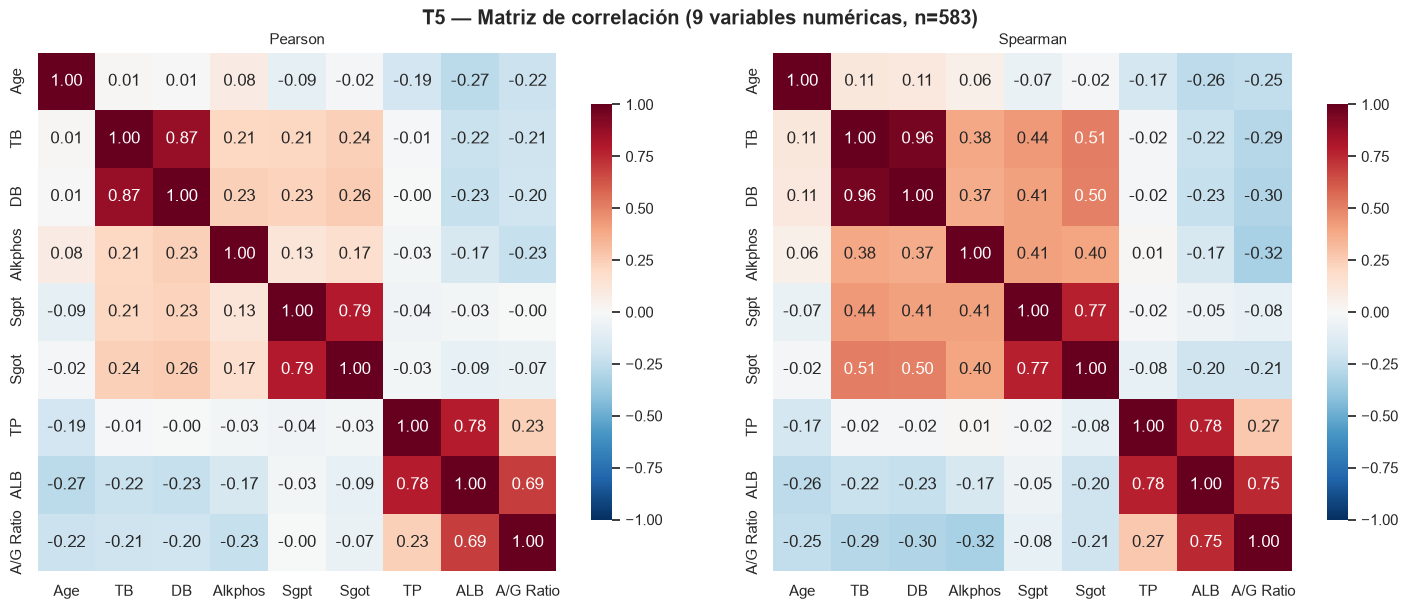

In [9]:
corr_pearson = df[NUMERIC_COLS].corr(method="pearson")
corr_spearman = df[NUMERIC_COLS].corr(method="spearman")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, (m, titulo) in zip(axes, [(corr_pearson, "Pearson"), (corr_spearman, "Spearman")]):
    sns.heatmap(m, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
                vmin=-1, vmax=1, ax=ax, square=True, cbar_kws={"shrink": 0.8})
    ax.set_title(titulo, fontsize=11)
fig.suptitle("T5 — Matriz de correlación (9 variables numéricas, n=583)", fontweight="bold")
fig.tight_layout()
plt.show()

In [10]:
pares = []
for i in range(len(NUMERIC_COLS)):
    for j in range(i + 1, len(NUMERIC_COLS)):
        r = corr_pearson.iloc[i, j]
        if abs(r) > CORR_THRESHOLD:
            pares.append({"var_1": NUMERIC_COLS[i], "var_2": NUMERIC_COLS[j],
                          "pearson": round(r, 3),
                          "spearman": round(corr_spearman.iloc[i, j], 3)})
print(f"Pares con |Pearson| > {CORR_THRESHOLD}:")
display(pd.DataFrame(pares))

Pares con |Pearson| > 0.7:


,var_1,var_2,pearson,spearman
0,TB,DB,0.875,0.959
1,Sgpt,Sgot,0.792,0.774
2,TP,ALB,0.784,0.779


**Respuesta.** Tres pares superan el umbral de |r| > 0.7:

| Par | Pearson | Spearman | Eje funcional |
|---|---|---|---|
| `TB` ↔ `DB` | **0.875** | **0.959** | Excreción biliar |
| `Sgpt` ↔ `Sgot` | **0.792** | 0.774 | Daño celular |
| `TP` ↔ `ALB` | **0.784** | 0.779 | Función sintética |

**Lo primero: dos de los tres no son hallazgos.** Los tres pares que superan el umbral son exactamente los tres ejes funcionales, y correlacionan porque **miden lo mismo por construcción**, no porque el análisis haya descubierto una relación. Conviene distinguir tres tipos:

| Tipo | Par | Por qué correlacionan | ¿Es un hallazgo? |
|---|---|---|---|
| **Contención** | `TB` ↔ `DB` | `DB` es una **fracción física** de `TB` | ❌ Definicional |
| **Algebraica** | `TP` ↔ `ALB` ↔ `A/G Ratio` | `A/G Ratio = ALB / (TP − ALB)` | ❌ Aritmética |
| **Fisiológica** | `Sgpt` ↔ `Sgot` | Dos enzimas distintas que responden al mismo daño | ✅ **El único empírico** |

Reportar `TB↔DB` = 0.96 como "descubrimos que las bilirrubinas están asociadas" sería un error de interpretación: equivale a descubrir que el total de una factura correlaciona con uno de sus renglones.

**Influencia en la selección de características.**

| Grupo | Qué conservar | Razón |
|---|---|---|
| `TB` ↔ `DB` | **`TB`** | `DB` está contenida en `TB`; con Spearman 0.96, `TB` sola retiene casi toda la señal ordinal. Es además el marcador de cribado inicial más usado. |
| `Sgpt` ↔ `Sgot` | **Ambas, con reserva** | La correlación es alta pero **no estructural**: ALT es casi exclusiva del hígado, AST también está en corazón y músculo. Straw & Wu (2022) muestran que **pesan distinto según el sexo**, así que descartar una borraría señal relevante para el análisis de equidad. Evaluar VIF antes de decidir. |
| `TP` ↔ `ALB` ↔ `A/G Ratio` | **`ALB` y `A/G Ratio`** | `ALB` es el marcador de síntesis más directo; `A/G Ratio` ya combina la información de las otras dos. `TP` es la más redundante. |

**Advertencia sobre `A/G Ratio`:** al ser función de `ALB` y `TP`, no aporta información nueva sino una **transformación** de información existente. Conservar las tres produciría multicolinealidad severa en cualquier modelo lineal.

**Lectura general:** correlación alta entre predictores significa **redundancia**, no causalidad — y en este dataset **dos de los tres pares son redundancia por definición, no por evidencia empírica**.

---

## Tarea 6 — Imputación de valores faltantes

> *"Aplica técnicas de imputación de datos faltantes: **media** para las variables numéricas y **moda** para las no numéricas. **Describe el proceso** y discute las **ventajas y desventajas** de cada técnica."*

In [11]:
# Paso previo: las 3 filas con DB > TB se marcan como faltantes en AMBAS columnas.
# No sabemos cual de los dos valores es el erroneo, asi que "corregir" seria inventar.
viol_db = flag_biochemical_violations(df)["db_gt_tb"]
df_t6 = df.copy()
df_t6.loc[viol_db, ["TB", "DB"]] = np.nan

print("=== Inventario de faltantes ===")
inv = pd.DataFrame({"n": df_t6.isna().sum()[df_t6.isna().sum() > 0]})
inv["pct"] = (100 * inv["n"] / len(df_t6)).round(2)
inv["tipo"] = ["medido pero imposible", "medido pero imposible", "nunca medido"]
display(inv)

# --- Imputacion por MEDIA de la variable numerica con faltantes ---
imp_media = SimpleImputer(strategy="mean")
faltan_ag = df_t6["A/G Ratio"].isna()
df_imp = df_t6.copy()
df_imp["A/G Ratio"] = imp_media.fit_transform(df_t6[["A/G Ratio"]]).ravel()

print("=== Imputacion por MEDIA (A/G Ratio) ===")
print(f"Filas imputadas: {int(faltan_ag.sum())}  (indices {list(df_t6.index[faltan_ag])})")
print(f"Media calculada sobre {int(df_t6['A/G Ratio'].notna().sum())} filas: {imp_media.statistics_[0]:.6f}")
print(f"Valor asignado: {imp_media.statistics_[0]:.2f}\n")

antes, despues = df_t6["A/G Ratio"], df_imp["A/G Ratio"]
display(pd.DataFrame({
    "n": [int(antes.notna().sum()), len(despues)],
    "media": [round(antes.mean(), 4), round(despues.mean(), 4)],
    "desv_estandar": [round(antes.std(), 4), round(despues.std(), 4)],
    "varianza": [round(antes.var(), 6), round(despues.var(), 6)],
}, index=["antes de imputar", "despues de imputar"]))
print(f"Reduccion de la varianza (variance shrinkage): "
      f"{100*(despues.var()-antes.var())/antes.var():+.3f}%")

# --- Imputacion por MODA de la variable categorica ---
imp_moda = SimpleImputer(strategy="most_frequent")
original = df_t6[CATEGORICAL_COLS[0]].copy()
df_imp[CATEGORICAL_COLS[0]] = imp_moda.fit_transform(df_t6[CATEGORICAL_COLS]).ravel()
print(f"\n=== Imputacion por MODA ({CATEGORICAL_COLS[0]}) ===")
print(f"Faltantes: {int(original.isna().sum())}  |  moda: {imp_moda.statistics_[0]}")
print(f"Filas alteradas: {int((df_imp[CATEGORICAL_COLS[0]] != original).sum())}  -> NO-OP")

=== Inventario de faltantes ===


,n,pct,tipo
TB,3,0.51,medido pero imposible
DB,3,0.51,medido pero imposible
A/G Ratio,4,0.69,nunca medido


=== Imputacion por MEDIA (A/G Ratio) ===
Filas imputadas: 4  (indices [209, 241, 253, 312])
Media calculada sobre 579 filas: 0.947064
Valor asignado: 0.95



,n,media,desv_estandar,varianza
antes de imputar,579,0.9471,0.3196,0.102139
despues de imputar,583,0.9471,0.3185,0.101437


Reduccion de la varianza (variance shrinkage): -0.687%

=== Imputacion por MODA (Gender) ===
Faltantes: 0  |  moda: Male
Filas alteradas: 0  -> NO-OP


In [12]:
print("=== Comparacion: imputacion determinista vs. por media ===")
print("A/G Ratio = ALB / (TP - ALB), donde TP - ALB = globulina\n")
print(f"Riesgo de division por cero (filas con TP == ALB): {int((df_t6['TP'] == df_t6['ALB']).sum())}\n")

comp = df_t6.loc[faltan_ag, ["Age", "Gender", "TP", "ALB"]].copy()
comp["globulina"] = (comp["TP"] - comp["ALB"]).round(2)
comp["determinista"] = (comp["ALB"] / comp["globulina"]).round(2)
comp["por_media"] = round(imp_media.statistics_[0], 2)
comp["error_relativo_%"] = (100 * (comp["determinista"] - comp["por_media"]).abs()
                            / comp["determinista"]).round(1)
display(comp)

verif = df_t6.dropna(subset=["A/G Ratio", "TP", "ALB"]).copy()
verif["err"] = (verif["ALB"] / (verif["TP"] - verif["ALB"]) - verif["A/G Ratio"]).abs()
print(f"Exactitud de la formula sobre las {len(verif)} filas con dato:")
print(f"  error medio: {verif['err'].mean():.4f}  |  mediana: {verif['err'].median():.4f}")
print(f"  filas con error > 0.05: {int((verif['err']>0.05).sum())} ({100*(verif['err']>0.05).mean():.1f}%)")

=== Comparacion: imputacion determinista vs. por media ===
A/G Ratio = ALB / (TP - ALB), donde TP - ALB = globulina

Riesgo de division por cero (filas con TP == ALB): 0



,Age,Gender,TP,ALB,globulina,determinista,por_media,error_relativo_%
209,45,Female,6.6,3.9,2.7,1.44,0.95,34.0
241,51,Male,6.5,3.1,3.4,0.91,0.95,4.4
253,35,Female,5.2,2.7,2.5,1.08,0.95,12.0
312,27,Male,8.5,4.8,3.7,1.30,0.95,26.9


Exactitud de la formula sobre las 579 filas con dato:
  error medio: 0.0514  |  mediana: 0.0310
  filas con error > 0.05: 191 (33.0%)


**Respuesta — descripción del proceso.**

**Paso previo.** Antes de imputar se marcaron como faltantes las 3 filas con `DB > TB` detectadas en T2, en **ambas** columnas. No hay evidencia de cuál de los dos valores es el erróneo, así que corregir uno sería inventar; y eliminar la fila descartaría el resto de la analítica de esos pacientes, que sí es válida. Esto eleva los faltantes de 4 a 10, de dos tipos distintos:

| Tipo | Cuántos | Significado |
|---|---|---|
| **Nunca medido** | 4 en `A/G Ratio` | El valor no existe en el registro |
| **Medido pero imposible** | 6 (`TB` y `DB`) | El valor existe pero viola una restricción bioquímica |

**Imputación aplicada.**

| Requisito | Variable | Estrategia | Filas afectadas | Valor |
|---|---|---|---|---|
| Media | `A/G Ratio` | `SimpleImputer(strategy="mean")` | **4** | **0.95** |
| Moda | `Gender` | `SimpleImputer(strategy="most_frequent")` | **0** | moda = `Male` |

La media se calculó sobre las 579 filas con dato: **0.947064**. La imputación por moda sobre `Gender` es un ***no-op***: esa columna no tiene faltantes, así que no alteró ninguna fila. Se implementa igualmente porque el enunciado la exige y porque deja el pipeline preparado para datos futuros — declararlo es más honesto que presentar un paso que no hizo nada.

**Los 6 faltantes de `TB`/`DB` se dejan sin imputar**, deliberadamente: son valores **medidos mal**, no ausentes, y rellenarlos con la media apilaría una invención sobre un error de laboratorio. Además, imputar destruye el registro de que eran desconocidos — se puede imputar después, no se puede des-imputar.

---

**El defecto de la media, medido en este dataset.**

**1. *Variance shrinkage*.** Rellenar cuatro huecos con el promedio añade cuatro observaciones exactamente en el centro, y la varianza baja un **0.687%** (0.102139 → 0.101437), mientras **la media no cambia en absoluto**. Con un 0.7% de faltantes el efecto es pequeño, pero **siempre va en la misma dirección**. Por eso los estadísticos de la Tarea 3 se reportan sobre datos originales.

**2. La media falla en 3 de las 4 filas.** `A/G Ratio` no es una medición independiente: es aritmética de `ALB` y `TP`, que sí están medidas en esas filas. Calculándola:

| Fila | `TP` | `ALB` | Globulina | **Valor calculado** | **Media asigna** | Error |
|---|---|---|---|---|---|---|
| 209 | 6.6 | 3.9 | 2.7 | **1.44** | 0.95 | **34.0%** |
| 241 | 6.5 | 3.1 | 3.4 | 0.91 | 0.95 | 4.4% |
| 253 | 5.2 | 2.7 | 2.5 | **1.08** | 0.95 | 12.0% |
| 312 | 8.5 | 4.8 | 3.7 | **1.30** | 0.95 | 26.9% |

Solo la fila 241 queda cerca, y por casualidad: ese paciente está próximo al promedio de la cohorte. La imputación por media **asigna el mismo número a todos, ignorando la información disponible de cada paciente**.

Con honestidad: la fórmula tampoco es exacta en la práctica. Sobre las 579 filas con dato, el error absoluto medio es **0.0514** y el **33.0%** supera 0.05, porque `TP` y `ALB` vienen redondeadas a un decimal y dividir cantidades redondeadas amplifica el error.

---

**Ventajas y desventajas de las técnicas de imputación.**

| Técnica | Ventajas | Desventajas |
|---|---|---|
| **Media** | Trivial de implementar y explicar · No altera la media de la variable · Estándar en `scikit-learn` | **Reduce la varianza** · **Distorsiona las correlaciones** · Ignora la información del resto de la fila · Sensible a extremos · Inadecuada si la distribución es asimétrica |
| **Mediana** | Todo lo anterior, pero **robusta a valores extremos** | Mismos problemas de varianza y correlaciones |
| **Moda** | Única opción simple para variables categóricas | **Refuerza el desbalance** de la clase mayoritaria |
| **Determinista (fórmula)** | **Usa la información real de cada fila** · No distorsiona la distribución · Reproducible | Requiere que exista la relación · Propaga el error de sus insumos · Riesgo de división por cero |
| **KNN / MICE** | Aprovecha la estructura multivariante | Costosa · Difícil de explicar · Puede filtrar información del test |
| **Eliminar filas** | No inventa ningún valor | **Pierde datos** · **Sesga la muestra** si los faltantes no son aleatorios |

**La desventaja de fondo**, común a media, mediana y moda: **tratan a todos los pacientes como intercambiables**. Asignan el mismo valor a una mujer de 30 años y a un hombre de 70, ignorando que los rangos de referencia difieren por sexo y por edad. Con 4 faltantes el efecto es despreciable, pero el razonamiento escala: con muchos huecos, imputar por media **homogeneizaría artificialmente los subgrupos**, y más agresivamente sobre el minoritario, que aporta menos observaciones al promedio.

**Jerarquía de calidad:** determinista > KNN/MICE > media/mediana > eliminar filas. **El paper que publicó este dataset usó imputación por media** — existiendo una relación algebraica exacta, es una limitación metodológica identificable.

---

## Tarea 7 — Normalización y estandarización

> *"Aplica **normalización MinMax** y **estandarización Z-Score** a las variables numéricas. **Describe el proceso**, compara **ventajas y desventajas** de cada técnica y **concluye cuál conviene** para este conjunto de datos."*

In [13]:
X = df_imp[NUMERIC_COLS]

X_minmax = pd.DataFrame(MinMaxScaler().fit_transform(X), columns=NUMERIC_COLS, index=X.index)
X_zscore = pd.DataFrame(StandardScaler().fit_transform(X), columns=NUMERIC_COLS, index=X.index)

print("=== Donde queda la MEDIANA de cada variable tras escalar ===\n")
evid = pd.DataFrame({
    "skew": X.skew().round(2),
    "min": X.min(), "max": X.max(),
    "mediana_original": X.median().round(2),
    "mediana_MinMax": X_minmax.median().round(4),
    "mediana_ZScore": X_zscore.median().round(4),
}).sort_values("skew", ascending=False)
evid["pct_del_rango"] = (100 * evid["mediana_MinMax"]).round(1)
display(evid)

print("--- Pacientes comprimidos bajo 0.1 tras MinMax ---")
for col in evid.index:
    pct = 100 * (X_minmax[col] < 0.1).mean()
    print(f"  {col:>10}: {pct:5.1f}%" + ("   <-- aplastada" if pct > 50 else ""))

print("\n--- Por que: cuanto estira un solo paciente el rango ---")
for col in SKEWED_COLS:
    q1, q3 = X[col].quantile([0.25, 0.75])
    print(f"  {col:>10}: rango={X[col].max()-X[col].min():8.1f}  IQR={q3-q1:7.1f}"
          f"  -> el rango es {(X[col].max()-X[col].min())/(q3-q1):5.1f}x el IQR")

=== Donde queda la MEDIANA de cada variable tras escalar ===



,skew,min,max,mediana_original,mediana_MinMax,mediana_ZScore,pct_del_rango
Sgot,10.55,10.0,4929.0,42.00,0.0065,-0.2353,0.6
Sgpt,6.55,10.0,2000.0,35.00,0.0126,-0.2505,1.3
TB,4.89,0.4,75.0,1.00,0.0080,-0.3712,0.8
Alkphos,3.77,63.0,2110.0,208.00,0.0708,-0.3402,7.1
DB,3.27,0.1,19.7,0.30,0.0102,-0.4177,1.0
A/G Ratio,1.00,0.3,2.8,0.95,0.2588,-0.0000,25.9
Age,-0.03,4.0,90.0,45.00,0.4767,0.0157,47.7
ALB,-0.04,0.9,5.5,3.10,0.4783,-0.0527,47.8
TP,-0.29,2.7,9.6,6.60,0.5652,0.1077,56.5


--- Pacientes comprimidos bajo 0.1 tras MinMax ---
        Sgot:  95.9%   <-- aplastada
        Sgpt:  94.2%   <-- aplastada
          TB:  89.4%   <-- aplastada
     Alkphos:  66.6%   <-- aplastada
          DB:  82.3%   <-- aplastada
   A/G Ratio:   9.9%
         Age:   1.7%
         ALB:   0.5%
          TP:   0.5%

--- Por que: cuanto estira un solo paciente el rango ---
          TB: rango=    74.6  IQR=    1.8  -> el rango es  41.4x el IQR
          DB: rango=    19.6  IQR=    1.0  -> el rango es  19.1x el IQR
     Alkphos: rango=  2047.0  IQR=  122.5  -> el rango es  16.7x el IQR
        Sgpt: rango=  1990.0  IQR=   37.5  -> el rango es  53.1x el IQR
        Sgot: rango=  4919.0  IQR=   62.0  -> el rango es  79.3x el IQR


**Respuesta — descripción del proceso.**

Ambas técnicas se aplicaron con `scikit-learn` sobre las 9 variables numéricas del dataset ya imputado:

- **MinMax** (`MinMaxScaler`): `(x − min) / (max − min)` → comprime al rango [0, 1].
- **Z-Score** (`StandardScaler`): `(x − μ) / σ` → centra en 0 con desviación 1.

**Por qué es necesario escalar.** Las variables viven en escalas incomparables: `Alkphos` llega a **2110** y `ALB` se mueve entre **0.9 y 5.5**. Sin ajustar, cualquier método basado en distancias o gradientes trataría a `Alkphos` como cientos de veces más importante que `ALB` — una diferencia que es **artefacto de las unidades**, no de la relevancia clínica.

---

**La evidencia: dónde queda la mediana con cada método.**

| Variable | *Skew* | Mediana MinMax | % del rango | Mediana Z-Score |
|---|---|---|---|---|
| `Sgot` | 10.55 | **0.0065** | **0.65%** | −0.2353 |
| `Sgpt` | 6.55 | **0.0126** | **1.26%** | −0.2505 |
| `TB` | 4.89 | **0.0080** | **0.80%** | −0.3712 |
| `Alkphos` | 3.77 | 0.0708 | 7.08% | −0.3402 |
| `DB` | 3.27 | **0.0102** | **1.02%** | −0.4177 |
| `A/G Ratio` | 1.00 | 0.2588 | 25.88% | −0.0000 |
| `Age` | −0.03 | 0.4767 | 47.67% | 0.0157 |
| `ALB` | −0.04 | 0.4783 | 47.83% | −0.0527 |
| `TP` | −0.29 | 0.5652 | 56.52% | 0.1077 |

Con MinMax, el paciente **mediano** de `Sgot` —el que deja a la mitad de la cohorte por debajo— queda en el **0.65% del rango**. Y no es aislado:

| Variable | Pacientes bajo 0.1 tras MinMax |
|---|---|
| `Sgot` | **95.9%** |
| `Sgpt` | **94.2%** |
| `TB` | **89.4%** |
| `DB` | **82.3%** |
| `Alkphos` | **66.6%** |

En `Sgot`, **96 de cada 100 pacientes quedan comprimidos en el primer 10% de la escala**. Toda la variabilidad clínicamente relevante —la diferencia entre alguien con 30 y alguien con 150— se aplasta hasta volverse indistinguible.

**Por qué ocurre.** MinMax divide por `max − min`, un denominador que fijan **exactamente dos pacientes**: el más bajo y el más alto. Con colas largas, el máximo está lejísimos del grueso:

| Variable | Rango | IQR | El rango es… |
|---|---|---|---|
| `Sgot` | 4919 | 62.0 | **79.3× el IQR** |
| `Sgpt` | 1990 | 37.5 | **53.1× el IQR** |
| `TB` | 74.6 | 1.8 | **41.4× el IQR** |

**El contraste que lo confirma:** `Age`, `ALB` y `TP` —asimetría cercana a cero— quedan en 47.7%, 47.8% y 56.5%, justo donde deberían. **El problema no es MinMax en abstracto: es MinMax aplicado a variables con cola larga.**

---

**Ventajas y desventajas.**

| | MinMax | Z-Score |
|---|---|---|
| Fórmula | `(x − min) / (max − min)` | `(x − μ) / σ` |
| Rango resultante | Acotado [0, 1] | Ilimitado |
| **Sensibilidad a extremos** | **Muy alta** — la escala la fijan 2 pacientes | Moderada — la fijan media y desviación de los 583 |
| Preserva la variabilidad del grueso | ❌ **No** en variables sesgadas | ✅ Sí |
| Valores nuevos fuera del rango | Se salen de [0, 1] | Sin problema |
| Ventaja propia | Rango predecible; requisito de algunas redes neuronales | Comparable entre variables; base de muchos métodos estadísticos |

**Conclusión: para este dataset conviene Z-Score.** Z-Score también se ve afectado por los valores extremos —media y desviación no son estadísticos robustos— pero **el efecto se reparte entre las 583 observaciones en lugar de recaer sobre dos**. Esa es toda la diferencia, y con las colas que tienen estas variables resulta decisiva.

**Alternativa superior a ambas:** aplicar `log1p` **antes** de escalar. Comprime la cola derecha sin borrar el orden entre pacientes, atacando la causa en vez de convivir con ella. Baja la asimetría de `Sgot` de 10.55 a 1.23. Cambia la interpretación de la variable —una diferencia pasa a ser un factor multiplicativo— y por eso debe declararse.

**Nota:** los modelos de árboles (Decision Tree, Random Forest, Gradient Boosting) son ***scale-invariant*** y no requieren escalado. Sí lo requieren los basados en distancia (KNN, SVM) y en gradiente (regresión logística, redes).

⚠️ **En el pipeline de modelado, el escalador debe ajustarse solo con el conjunto de entrenamiento**, dentro de un `Pipeline`. Ajustarlo sobre el dataset completo filtra información del test e infla las métricas. Aquí es aceptable porque no se entrena ningún modelo.

---

## Tarea 8 — Identificación de valores atípicos

> *"Detecta **valores atípicos** en `Sgot`, `TP`, `ALB` y `A/G Ratio` mediante **boxplots**. **Cuantifica** cuántos hay y **describe los patrones** observados."*

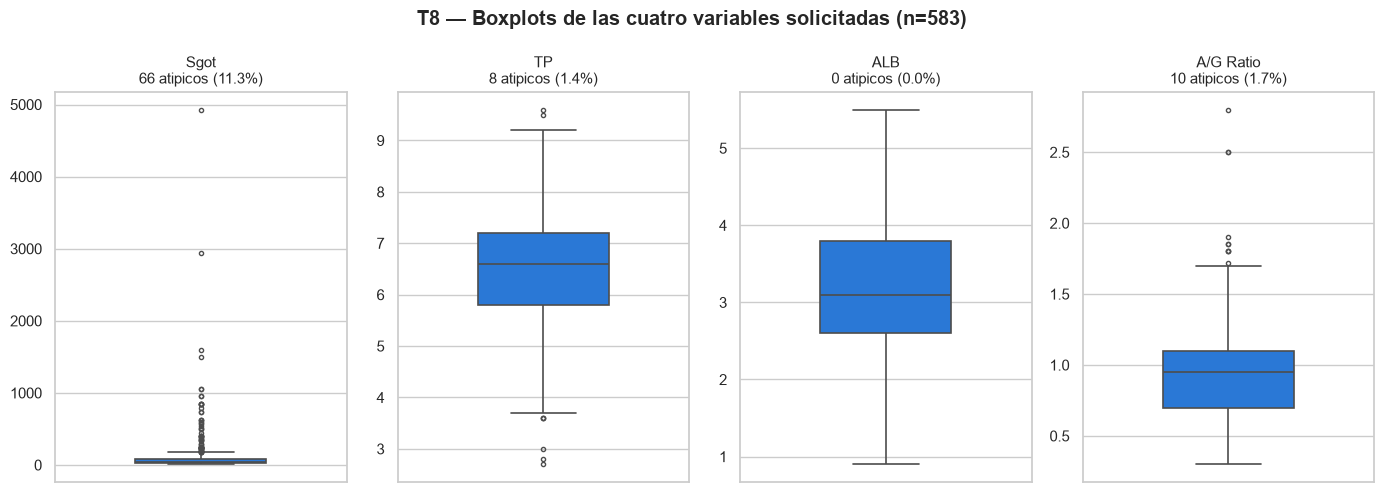

In [14]:
COLS_T8 = ["Sgot", "TP", "ALB", "A/G Ratio"]


def limites_tukey(s):
    q1, q3 = s.quantile([0.25, 0.75])
    return q1 - IQR_MULTIPLIER * (q3 - q1), q3 + IQR_MULTIPLIER * (q3 - q1)


fig, axes = plt.subplots(1, 4, figsize=(14, 5))
for ax, col in zip(axes, COLS_T8):
    sns.boxplot(y=df_imp[col], ax=ax, color="#2a78d6", width=0.45,
                fliersize=3, linewidth=1.2, saturation=1)
    lo, hi = limites_tukey(df_imp[col])
    n_out = int(((df_imp[col] < lo) | (df_imp[col] > hi)).sum())
    ax.set_title(f"{col}\n{n_out} atipicos ({100*n_out/len(df_imp):.1f}%)", fontsize=10.5)
    ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("T8 — Boxplots de las cuatro variables solicitadas (n=583)", fontweight="bold")
fig.tight_layout()
plt.show()

In [15]:
print(f"=== Cuantificacion por regla de Tukey (Q1 - {IQR_MULTIPLIER}*IQR, Q3 + {IQR_MULTIPLIER}*IQR) ===\n")
filas = []
for col in COLS_T8:
    lo, hi = limites_tukey(df_imp[col])
    bajo, alto = (df_imp[col] < lo), (df_imp[col] > hi)
    filas.append({"variable": col, "Q1": round(df_imp[col].quantile(.25), 2),
                  "Q3": round(df_imp[col].quantile(.75), 2),
                  "limite_inf": round(lo, 2), "limite_sup": round(hi, 2),
                  "n_atipicos": int((bajo | alto).sum()),
                  "pct": round(100 * (bajo | alto).mean(), 1),
                  "por_debajo": int(bajo.sum()), "por_encima": int(alto.sum())})
display(pd.DataFrame(filas).set_index("variable"))

print("=== Son atipicos ERRONEOS o solo ESTADISTICOS? ===")
print("Contraste contra limites biologicamente POSIBLES (no rangos de referencia):\n")
for col, (lo_b, hi_b) in BIOLOGICAL_LIMITS.items():
    fuera = int(((df_imp[col] < lo_b) | (df_imp[col] > hi_b)).sum())
    fuente = "fuente citada" if col in BIOLOGICAL_LIMITS_SOURCED else "estimacion del equipo"
    print(f"  {col:>10}: valores fuera del rango posible [{lo_b}, {hi_b}] ({fuente}) -> {fuera}")

print("\nEl caso mas extremo (Sgot maximo):")
display(df_imp.loc[[df_imp["Sgot"].idxmax()]])

=== Cuantificacion por regla de Tukey (Q1 - 1.5*IQR, Q3 + 1.5*IQR) ===



,Q1,Q3,limite_inf,limite_sup,n_atipicos,pct,por_debajo,por_encima
variable,,,,,,,,
Sgot,25.0,87.0,-68.0,180.0,66,11.3,0,66
TP,5.8,7.2,3.7,9.3,8,1.4,6,2
ALB,2.6,3.8,0.8,5.6,0,0.0,0,0
A/G Ratio,0.7,1.1,0.1,1.7,10,1.7,0,10


=== Son atipicos ERRONEOS o solo ESTADISTICOS? ===
Contraste contra limites biologicamente POSIBLES (no rangos de referencia):

          TP: valores fuera del rango posible [2.0, 12.0] (estimacion del equipo) -> 0
         ALB: valores fuera del rango posible [0.5, 6.5] (estimacion del equipo) -> 0
   A/G Ratio: valores fuera del rango posible [0.1, 5.0] (estimacion del equipo) -> 0
        Sgot: valores fuera del rango posible [1, 7446] (fuente citada) -> 0

El caso mas extremo (Sgot maximo):


,Age,Gender,TB,DB,Alkphos,Sgpt,Sgot,TP,ALB,A/G Ratio,Selector
135,66,Male,11.3,5.6,1110,1250,4929,7.0,2.4,0.5,1


**Respuesta — cuantificación.**

| Variable | Q1 | Q3 | Límites de Tukey | **Atípicos** | % | Por debajo | Por encima |
|---|---|---|---|---|---|---|---|
| **`Sgot`** | 25.0 | 87.0 | [−68.0, 180.0] | **66** | **11.3%** | 0 | **66** |
| **`TP`** | 5.80 | 7.20 | [3.70, 9.30] | **8** | 1.4% | **6** | 2 |
| **`ALB`** | 2.60 | 3.80 | [0.80, 5.60] | **0** | 0.0% | 0 | 0 |
| **`A/G Ratio`** | 0.70 | 1.10 | [0.10, 1.70] | **10** | 1.7% | 0 | **10** |

> ⚠️ **Transparencia sobre las fuentes (añadido tras auditoría externa, 2026-08-15).** Los cuatro límites biológicos usados más abajo no tenían fuente citada. Se investigó: para `Sgot` sí existe literatura verificable — Chang et al. (2007), *Study on Analytical and Clinically Reportable Ranges*, Korean J Clin Lab Sci 39(1):31-36 — que mide con instrumentos reales hasta qué valor un ensayo de AST mantiene linealidad (rango clínicamente reportable 24–7 446 U/L). Se adopta su **techo** (7 446 U/L), más estricto que el 20 000 sin fuente usado antes; el máximo del ILPD (4 929) sigue quedando por debajo. El **piso** de `Sgot` se mantiene en 1 (trivial, sin necesidad de cita): el piso de 24 de ese estudio **no** es un piso biológico -- es el mínimo verificado por *esa prueba de calibración de instrumento*, y usarlo habría marcado como "erróneos" a 124 pacientes del ILPD con AST bajo pero sano (mínimo observado = 10). Para `TP`, `ALB` y `A/G Ratio` no se encontró una fuente publicada verificable con la confianza que exige el protocolo del proyecto (búsqueda documentada en `docs/fuentes/Consulta_5.md`): se declaran explícitamente como una **estimación razonada por el equipo**, no una cita clínica.

**Patrones observados.**

**`Sgot` — 66 atípicos, todos por arriba.** Uno de cada nueve pacientes queda fuera del límite superior y **ninguno por debajo**. Tiene sentido clínico: AST es una enzima que se derrama a la sangre cuando la célula hepática se rompe, así que un valor bajo simplemente significa que no hay destrucción celular. **No existe un "AST peligrosamente bajo"**: la cola solo puede crecer hacia arriba, y hacia arriba está la gravedad.

**`TP` — 8 atípicos, y la dirección es lo interesante.** Seis están **por debajo** y solo dos por encima. `TP` mide la producción total de proteínas del hígado, y en este eje **bajo = malo**. Esos seis pacientes con proteína total anormalmente baja son casos de fallo de la función sintética, es decir daño crónico avanzado. Es la única de las cuatro donde la cola relevante apunta hacia abajo.

**`ALB` — cero atípicos.** Ningún paciente queda fuera de los límites. No significa que todos tengan albúmina normal: significa que la distribución es **estrecha y simétrica** (*skewness* −0.04), sin cola en ninguna dirección. La regla de Tukey no detecta nada porque no hay nada que sobresalga **estadísticamente**, aunque clínicamente sí haya pacientes con albúmina baja. **"Atípico estadístico" y "anormal clínico" no son lo mismo.**

**`A/G Ratio` — 10 atípicos, todos por arriba.** Al ser un cociente, se dispara cuando el denominador (la globulina) es pequeño.

**El patrón general:** en tres de las cuatro variables **todos los atípicos están en el mismo extremo**. No es casualidad ni error de medición: es el reflejo directo de la fisiología. Las enzimas y los desechos se acumulan cuando algo falla; las proteínas fabricadas por el hígado caen cuando la fábrica se deteriora. **Un método que asuma colas simétricas no encaja con estos datos.**

---

**Ninguno de los atípicos es erróneo.**

Contrastados contra límites biológicamente posibles —no contra rangos de referencia, sino contra los límites de lo que puede existir— **cero valores quedan fuera**. Los 84 atípicos son todos **estadísticos**: raros, pero perfectamente posibles.

El caso más extremo lo confirma: el paciente con `Sgot` = 4929 es un hombre de 66 años con `TB` = 11.3 (nueve veces el techo normal), `Alkphos` = 1110, `Sgpt` = 1250 y `ALB` = 2.4. **Los tres ejes hepáticos alterados a la vez y de forma coherente entre sí** — no es un error de tecleo, es un paciente en fallo hepático agudo grave.

**Decisión: no se elimina ningún valor atípico.** Si fueran errores, eliminarlos limpiaría el dataset; como son pacientes reales y graves, eliminarlos **borraría exactamente los casos que más importa detectar**. Un modelo de cribado entrenado sin ellos aprendería a reconocer enfermedad leve y fallaría en la severa, subiendo la tasa de falsos negativos donde el coste clínico es máximo.

**Alternativa a eliminar:** la transformación `np.log1p` comprime la cola derecha **sin borrar información ni alterar el orden entre pacientes**. Reduce la asimetría de `Sgot` de 10.55 a **1.23** y su conteo de atípicos de 66 a 22 — pero conviene entender que **eso no elimina pacientes: cambia la escala en la que se mide la distancia**, y con ella la pregunta que se responde.

---

## Índice de análisis complementarios

Los siguientes análisis **exceden lo que pide el enunciado** y no se incluyen aquí para no diluir la correspondencia entre cada celda y cada tarea. Viven en los notebooks modulares del repositorio, todos ejecutables y con su interpretación completa.

| Análisis | Qué aporta | Dónde |
|---|---|---|
| **Sensibilidad del umbral de ALT por sexo** | Al pasar del umbral unisex (40 U/L) al diferenciado por sexo (30 H / 19 M), se reclasifica el **49.3%** de las mujeres frente al **15.6%** de los hombres | `02_eda.ipynb` |
| **`Alkphos` confundida por edad** | La ALP es dependiente de la edad por el crecimiento óseo; el umbral global marca al 16.0% de los menores frente al 8.0% de su propio umbral | `02_eda.ipynb` |
| **Cociente De Ritis (AST/ALT)** | Indicio sugerente de heterogeneidad etiológica bajo una etiqueta binaria | `02_eda.ipynb`, `02c_eda_clustering.ipynb` |
| **Clustering jerárquico edad × sexo** | Demuestra empíricamente por qué no se pueden derivar umbrales de esta cohorte hospitalaria | `02c_eda_clustering.ipynb` |
| **Separación por variable (delta de Cliff)** | ALT queda 4.ª de 9 en capacidad de separación — el foco en ALT viene de la evidencia bibliográfica, no de la fuerza de la señal | `02c_eda_clustering.ipynb` |
| **Outliers estratificados por sexo y edad** | El umbral único de Tukey subdetecta en mujeres y el sesgo etario se invierte según la variable | `03_preprocessing.ipynb` |
| **Iteraciones CRISP-DM (Loops A, B, C)** | Registro fechado de cada hallazgo que obligó a revisar una fase anterior | `docs/CHANGELOG_iteraciones.md` |
| **Decisiones de ingeniería** | Cuatro ADR: gitflow, entorno, holdout, umbrales de referencia | `docs/adr/` |
| **Fundamentación bibliográfica** | Cuatro consultas de investigación con sus fuentes primarias | `docs/fuentes/` |